# How the energy grid resolution affects the xs perturbation

In [1]:
import sandy
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

## Retrieve ENDF-6 file

In [3]:
tape = sandy.get_endf6_file("endfb_80", "xs", 942390)

## Create PENDF files by parametrically varying reconstruction tolerance ERR

In [4]:
pendf_1 = tape.get_pendf(
    purr=False,
    heatr=False,
    gaspr=False,
    verbose=True,
    err=1,
)
xs_1 = sandy.Xs.from_endf6(pendf_1)

    If you want to process 0K cross sections use `temperature=0.1`.
    


 - Dumping NJOY input file to output stream...


moder
20 -21 /
reconr
-21 -22 /
'sandy runs njoy'/
9437 0 0 /
1.0 0. /
0/
moder
-22 30 /
stop



 njoy 2016.78  03Feb25                                       12/01/25 14:50:23
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                 1.7s


                                                                          1.9s
 *****************************************************************************


In [5]:
pendf_01 = tape.get_pendf(err=0.1)
xs_01 = sandy.Xs.from_endf6(pendf_01)

    If you want to process 0K cross sections use `temperature=0.1`.
    



 njoy 2016.78  03Feb25                                       12/01/25 14:50:27
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                 2.9s


                                                                          3.4s
 *****************************************************************************


In [6]:
pendf_001 = tape.get_pendf(err=0.01)
xs_001 = sandy.Xs.from_endf6(pendf_001)

    If you want to process 0K cross sections use `temperature=0.1`.
    



 njoy 2016.78  03Feb25                                       12/01/25 14:50:32
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                 7.3s


                                                                          8.5s
 *****************************************************************************


In [7]:
pendf_0001 = tape.get_pendf(err=0.001)
xs_0001 = sandy.Xs.from_endf6(pendf_0001)

    If you want to process 0K cross sections use `temperature=0.1`.
    



 njoy 2016.78  03Feb25                                       12/01/25 14:50:44
 *****************************************************************************

 moder...                                                                 0.0s



 reconr...                                                                0.5s

 ---message from rdf2bw---calculation of angular distribution not installed.



 moder...                                                                18.1s


                                                                         21.3s
 *****************************************************************************


## Extract cross sections and perturb them in energy bin

In [8]:
pert_coeff = 1
ipert = 25

egrid = sandy.energy_grids.SCALE238
estart = egrid[ipert]
estop = egrid[ipert+1]

pert = sandy.Pert([1, 1 + pert_coeff], index=[estart, estop])

print(
    f"""
Perturb fission xs in range ({estart}, {estop}) eV by a factor {pert_coeff*100} %.
Perturbation object is:
{pert}
"""
 )


Perturb fission xs in range (0.175, 0.19999999999999998) eV by a factor 100 %.
Perturbation object is:
ENERGY
(0.0, 0.175]                   1.00000e+00
(0.175, 0.19999999999999998]   2.00000e+00
dtype: float64



In [9]:
mat = tape.mat[0]
mt = 18

xspert_1 = xs_1.custom_perturbation(mat, mt, pert)
xspert_01 = xs_01.custom_perturbation(mat, mt, pert)
xspert_001 = xs_001.custom_perturbation(mat, mt, pert)
xspert_0001 = xs_0001.custom_perturbation(mat, mt, pert)

## Analyize how the perturbation was implemented

In [10]:
def apply_mask(xs, estart, estop):
    mask = (xs.data.index >= estart) & (xs.data.index <= estop)
    return xs.data.loc[mask]

### ERR=1

In [11]:
print(
    f"""
No point was was found in the selected energy interval with a very low reconstruction tolerance.

{apply_mask(xs_1, estart, estop)[mat, mt].rename("ORIGINAL")}

Points {estart} and {estop} were interpolated and then perurbed in the perturbed xs.

{apply_mask(xspert_1, estart, estop)[mat, mt].rename("PERTURBED")}
"""
)


No point was was found in the selected energy interval with a very low reconstruction tolerance.

Series([], Name: ORIGINAL, dtype: float64)

Points 0.175 and 0.19999999999999998 were interpolated and then perurbed in the perturbed xs.

E
1.75000e-01   6.96120e+02
2.00000e-01   1.68896e+03
Name: PERTURBED, dtype: float64



### ERR=0.001

In [12]:
print(
    f"""
Many points were found.

{apply_mask(xs_0001, estart, estop)[mat, mt].rename("ORIGINAL")}

Point {estop} was added to the perturbed xs because not present in the original file.

{apply_mask(xspert_0001, estart, estop)[mat, mt].rename("PERTURBED")}
"""
)


Many points were found.

E
1.75000e-01   6.53029e+02
1.76563e-01   6.61959e+02
1.78125e-01   6.71226e+02
1.79688e-01   6.80842e+02
1.81250e-01   6.90821e+02
1.82812e-01   7.01175e+02
1.84375e-01   7.11919e+02
1.85938e-01   7.23068e+02
1.87500e-01   7.34637e+02
1.89062e-01   7.46644e+02
1.90625e-01   7.59105e+02
1.92188e-01   7.72038e+02
1.93750e-01   7.85462e+02
1.95312e-01   7.99397e+02
1.96875e-01   8.13864e+02
1.98437e-01   8.28884e+02
Name: ORIGINAL, dtype: float64

Point 0.19999999999999998 was added to the perturbed xs because not present in the original file.

E
1.75000e-01   6.53029e+02
1.76563e-01   1.32392e+03
1.78125e-01   1.34245e+03
1.79688e-01   1.36168e+03
1.81250e-01   1.38164e+03
1.82812e-01   1.40235e+03
1.84375e-01   1.42384e+03
1.85938e-01   1.44614e+03
1.87500e-01   1.46927e+03
1.89062e-01   1.49329e+03
1.90625e-01   1.51821e+03
1.92188e-01   1.54408e+03
1.93750e-01   1.57092e+03
1.95312e-01   1.59879e+03
1.96875e-01   1.62773e+03
1.98437e-01   1.65777e+03
2.00000

### Visual analysis

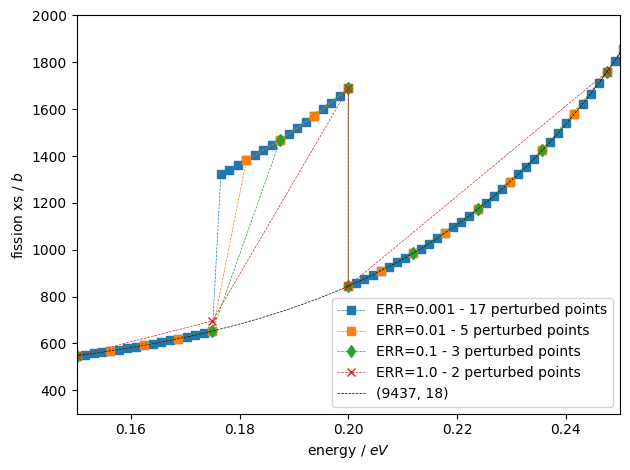

In [13]:
fig, ax = plt.subplots()

count = ((xspert_0001.data.index >= estart) & (xspert_0001.data.index <= estop)).sum()
ax = xspert_0001.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"ERR=0.001 - {count} perturbed points")

count = ((xspert_001.data.index >= estart) & (xspert_001.data.index <= estop)).sum()
ax = xspert_001.data[mat, mt].plot(marker="s", ax=ax, ls="--", lw=.5, label=f"ERR=0.01 - {count} perturbed points")

count = ((xspert_01.data.index >= estart) & (xspert_01.data.index <= estop)).sum()
ax = xspert_01.data[mat, mt].plot(marker="d", ax=ax, ls="--", lw=.5, label=f"ERR=0.1 - {count} perturbed points")

count = ((xspert_1.data.index >= estart) & (xspert_1.data.index <= estop)).sum()
ax = xspert_1.data[mat, mt].plot(marker="x", ax=ax, ls="--", lw=.5, label=f"ERR=1.0 - {count} perturbed points")

ax = xs_0001.data[mat, mt].plot(ls="--", lw=.5, c="k", ax=ax)

ax.set(xlim=(0.15, 0.25), ylim=(300, 2000), xlabel='energy / $eV$', ylabel="fission xs / $b$")
ax.legend(loc=4)

fig.tight_layout()

## Conclusion

Using a low value for the reconstruction tolerance parameter ERR is necessary to reproduce the expected perturbation behavior.

Alternatively, additional points must be added manually to the cross sections.